GPU-accelerated Monte Carlo Simulation for Pi Estimation

In [ ]:
!pip install numba
import numpy as np
import math
import time
import matplotlib.pyplot as plt
from numba import cuda


CPU BASELINE IMPLEMENTATION

In [ ]:
import random

def pi_cpu_python(n):
    inside = 0
    for _ in range(n):
        x = random.random()
        y = random.random()
        if x*x + y*y <= 1:
            inside += 1
    return 4 * inside / n

start = time.time()
print("π (CPU Python):", pi_cpu_python(200_000))
print("CPU Python time:", time.time() - start, "seconds")


π (CPU Python): 3.14198
CPU Python time: 0.07035517692565918 seconds


In [ ]:
def pi_cpu_numpy(n):
    x = np.random.rand(n)
    y = np.random.rand(n)
    inside = np.sum(x*x + y*y <= 1)
    return 4 * inside / n

start = time.time()
print("π (CPU NumPy):", pi_cpu_numpy(5_000_000))
print("CPU NumPy time:", time.time() - start, "seconds")


π (CPU NumPy): 3.1413144
CPU NumPy time: 0.22787022590637207 seconds


GPU VERSION (NUMBA CUDA)

In [ ]:
@cuda.jit
def mc_kernel_basic(xs, ys, results):
    i = cuda.grid(1)
    if i < xs.size:
        x = xs[i]
        y = ys[i]
        results[i] = 1 if x*x + y*y <= 1 else 0


In [ ]:
def pi_gpu_basic(n, threads=256):
    xs = cuda.to_device(np.random.rand(n).astype(np.float32))
    ys = cuda.to_device(np.random.rand(n).astype(np.float32))
    results = cuda.device_array(n, dtype=np.int32)

    blocks = (n + threads - 1) // threads

    mc_kernel_basic[blocks, threads](xs, ys, results)
    inside = results.copy_to_host().sum()

    return 4 * inside / n


In [ ]:
start = time.time()
print("π (GPU Basic):", pi_gpu_basic(10_000_000))
print("GPU Basic time:", time.time() - start, "seconds")


π (GPU Basic): 3.1421124
GPU Basic time: 0.5185582637786865 seconds


FULLY OPTIMIZED GPU VERSION (atomic add)

In [ ]:
@cuda.jit
def mc_kernel_optimized(xs, ys, counter):
    i = cuda.grid(1)
    if i < xs.size:
        x = xs[i]
        y = ys[i]
        if x*x + y*y <= 1:
            cuda.atomic.add(counter, 0, 1)


In [ ]:
def pi_gpu_optimized(n, threads=256):
    xs = cuda.to_device(np.random.rand(n).astype(np.float32))
    ys = cuda.to_device(np.random.rand(n).astype(np.float32))

    counter = cuda.to_device(np.array([0], dtype=np.int32))

    blocks = (n + threads - 1) // threads

    mc_kernel_optimized[blocks, threads](xs, ys, counter)

    inside = counter.copy_to_host()[0]
    return 4 * inside / n


In [ ]:
start = time.time()
print("π (GPU Optimized):", pi_gpu_optimized(20_000_000))
print("GPU Optimized time:", time.time() - start, "seconds")


π (GPU Optimized): 3.1408858
GPU Optimized time: 0.6381790637969971 seconds


STREAMED VERSION (HOST–DEVICE OVERLAP)

In [ ]:
@cuda.jit
def mc_kernel_stream(xs, ys, counter):
    i = cuda.grid(1)
    if i < xs.size:
        x = xs[i]
        y = ys[i]
        if x*x + y*y <= 1:
            cuda.atomic.add(counter, 0, 1)


In [ ]:
def pi_gpu_streamed(total_n, batch_size=4_000_000, threads=256):
    num_batches = total_n // batch_size
    streams = [cuda.stream() for _ in range(3)]

    counters = []
    blocks = (batch_size + threads - 1) // threads

    for b in range(num_batches):
        stream = streams[b % 3]

        # CPU generates batch random numbers WHILE GPU computes other batches
        xs_host = np.random.rand(batch_size).astype(np.float32)
        ys_host = np.random.rand(batch_size).astype(np.float32)

        # allocate device memory for results
        xs_dev = cuda.to_device(xs_host, stream=stream)
        ys_dev = cuda.to_device(ys_host, stream=stream)
        counter = cuda.to_device(np.array([0], dtype=np.int32), stream=stream)

        # launch kernel asynchronously
        mc_kernel_stream[blocks, threads, stream](xs_dev, ys_dev, counter)

        counters.append(counter)

    # synchronization
    for s in streams:
        s.synchronize()

    # combine results
    total_inside = 0
    for c in counters:
        total_inside += c.copy_to_host()[0]

    return 4 * total_inside / total_n


In [ ]:
start = time.time()
print("π (GPU Streamed):", pi_gpu_streamed(40_000_000))
print("GPU Streamed time:", time.time() - start, "seconds")


π (GPU Streamed): 3.1416887
GPU Streamed time: 0.8182182312011719 seconds


Performance Comparison

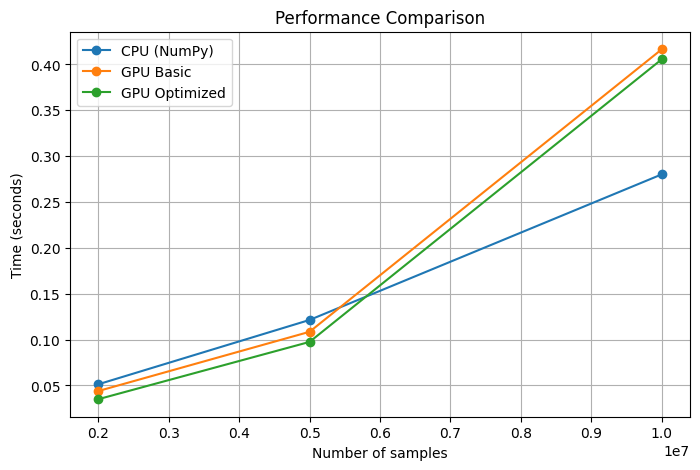

In [ ]:
sizes = [2_000_000, 5_000_000, 10_000_000]
times_cpu = []
times_gpu = []
times_gpu_opt = []

for n in sizes:
    # CPU NumPy
    start = time.time()
    pi_cpu_numpy(n)
    times_cpu.append(time.time() - start)

    # GPU basic
    start = time.time()
    pi_gpu_basic(n)
    times_gpu.append(time.time() - start)

    # GPU optimized
    start = time.time()
    pi_gpu_optimized(n)
    times_gpu_opt.append(time.time() - start)

plt.figure(figsize=(8,5))
plt.plot(sizes, times_cpu, marker='o', label="CPU (NumPy)")
plt.plot(sizes, times_gpu, marker='o', label="GPU Basic")
plt.plot(sizes, times_gpu_opt, marker='o', label="GPU Optimized")
plt.xlabel("Number of samples")
plt.ylabel("Time (seconds)")
plt.title("Performance Comparison")
plt.legend()
plt.grid(True)
plt.show()


True GPU-Side RNG Version

In [ ]:
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32

In [ ]:
@cuda.jit
def mc_kernel_fast_rng(rng_states, n, counter):
    i = cuda.grid(1)
    if i >= n:
        return

    # use the blockIdx.x RNG state
    bid = cuda.blockIdx.x

    # generate x,y using xoroshiro RNG
    x = xoroshiro128p_uniform_float32(rng_states, bid)
    y = xoroshiro128p_uniform_float32(rng_states, bid)

    if x*x + y*y <= 1.0:
        cuda.atomic.add(counter, 0, 1)


In [ ]:
def pi_gpu_fast_rng(n, threads=256):
    blocks = (n + threads - 1) // threads

    # ONLY blocks RNG states, not n states
    rng_states = create_xoroshiro128p_states(blocks, seed=1234)

    counter = cuda.to_device(np.array([0], dtype=np.int32))

    mc_kernel_fast_rng[blocks, threads](rng_states, n, counter)

    inside = counter.copy_to_host()[0]
    return 4 * inside / n


In [ ]:
start = time.time()
print("π (GPU FAST RNG):", pi_gpu_fast_rng(20_000_000))
print("GPU FAST RNG Time:", time.time() - start, "seconds")


π (GPU FAST RNG): 3.147264
GPU FAST RNG Time: 0.12235403060913086 seconds


FINAL COMPARISON

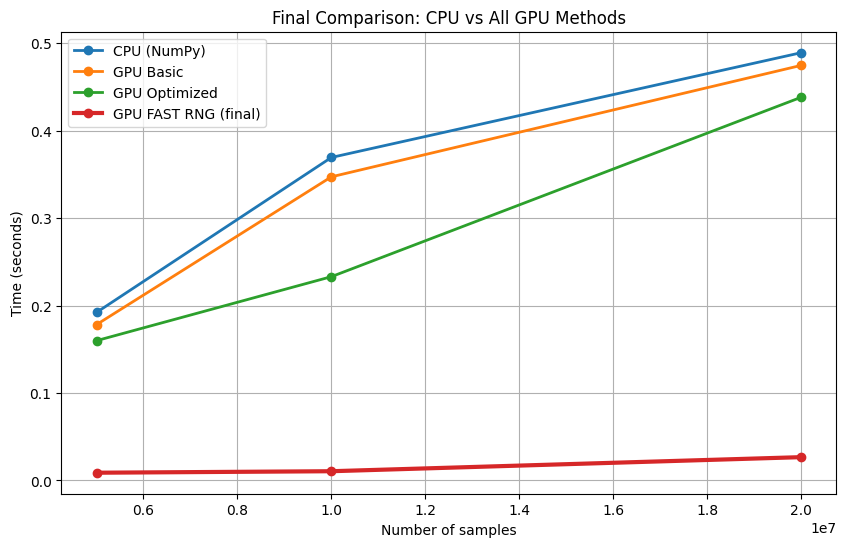

In [ ]:
sizes = [5_000_000, 10_000_000, 20_000_000]

times_cpu = []
times_gpu_basic = []
times_gpu_opt = []
times_gpu_fast_rng = []

for n in sizes:

    # CPU NumPy baseline
    start = time.time()
    pi_cpu_numpy(n)
    times_cpu.append(time.time() - start)

    # GPU Basic
    start = time.time()
    pi_gpu_basic(n)
    times_gpu_basic.append(time.time() - start)

    # GPU Optimized
    start = time.time()
    pi_gpu_optimized(n)
    times_gpu_opt.append(time.time() - start)

    # GPU FAST RNG (true GPU-side RNG)
    start = time.time()
    pi_gpu_fast_rng(n)
    times_gpu_fast_rng.append(time.time() - start)


# ---------------------- Plot all together ----------------------

plt.figure(figsize=(10,6))

plt.plot(sizes, times_cpu, marker='o', label="CPU (NumPy)", linewidth=2)
plt.plot(sizes, times_gpu_basic, marker='o', label="GPU Basic", linewidth=2)
plt.plot(sizes, times_gpu_opt, marker='o', label="GPU Optimized", linewidth=2)
plt.plot(sizes, times_gpu_fast_rng, marker='o', label="GPU FAST RNG (final)", linewidth=3)

plt.xlabel("Number of samples")
plt.ylabel("Time (seconds)")
plt.title("Final Comparison: CPU vs All GPU Methods")
plt.grid(True)
plt.legend()
plt.show()
